# Cross-platform arbitrage opportunities — first pass

Quick draft on the 2026-07-21 collection window (`db/arbitrage/arb_data.db`,
frozen by `db/arbitrage/prepare_arb_analysis.py`).

**Definitions**

- **Tick** — one row of `arb_aligned`: a top-of-book change on either venue,
  carrying the latest book from both venues (already normalised onto the
  Kalshi YES basis).
- **Gross edge** — per tick, per direction:
  buy-Poly/sell-Kalshi = `k_bid − p_ask`; buy-Kalshi/sell-Poly = `p_bid − k_ask`.
- **Opportunity (episode)** — a maximal run of consecutive ticks on one match,
  one direction, with gross edge > 0. Consecutive ticks of the same
  opportunity count once. A run is split if >300 s pass between its ticks.
  Duration runs from the first arb tick to the tick that kills the edge
  (censored at the last observed tick if the data ends first).
- **Fees** — taker on both legs, from the wiki
  ([[kalshi-fees]]: 0.07·C·(1−C) per contract;
  [[polymarket-us-fees]]: 0.06·p·(1−p) per contract, July 2026 schedule).
  Net edge = gross edge − both fees at the executed prices. An episode
  "clears fees" if its best tick has net edge > 0.
- **Freshness** — a tick is used only if both legs were updated within the
  last 300 s (guards against edges that are just one venue's dead feed).
- **Match quality** — `prepare_arb_analysis.py` auto-corrects matches whose
  Polymarket book was recorded on the wrong side (mids agree as complements)
  and stores each match's residual median cross-venue mid gap as
  `arb_matches.mid_gap`. Which gap disqualifies a match is chosen below,
  visibly.

Books whose top level holds under 1 contract (dust residue from the Kalshi
book reconstruction, quoted at phantom prices) are dropped upstream in
`prepare_arb_analysis.py`.

In [1]:
import duckdb
import polars as pl
import matplotlib.pyplot as plt

con = duckdb.connect("../db/arbitrage/arb_data.db", read_only=True)
print(con.sql("SELECT * FROM arb_build_info").pl())

df = con.sql("""
    SELECT a.match_id, m.market, a.ts,
           a.k_bid::DOUBLE AS k_bid, a.k_ask::DOUBLE AS k_ask,
           a.k_bidsz::DOUBLE AS k_bidsz, a.k_asksz::DOUBLE AS k_asksz,
           a.p_bid::DOUBLE AS p_bid, a.p_ask::DOUBLE AS p_ask,
           a.p_bidsz::DOUBLE AS p_bidsz, a.p_asksz::DOUBLE AS p_asksz,
           a.k_age_s::DOUBLE AS k_age_s, a.p_age_s::DOUBLE AS p_age_s
    FROM arb_aligned a JOIN arb_matches m USING (match_id)
    ORDER BY a.match_id, a.ts
""").pl()

n_all = df.height
print(f"{n_all:,} aligned ticks")

shape: (1, 7)
┌──────────────┬────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┐
│ raw_snapshot ┆ events ┆ aligned_tick ┆ matches_both ┆ matches_flip ┆ first_ts     ┆ last_ts      │
│ s            ┆ ---    ┆ s            ┆ ---          ┆ ped          ┆ ---          ┆ ---          │
│ ---          ┆ i64    ┆ ---          ┆ i64          ┆ ---          ┆ datetime[μs] ┆ datetime[μs] │
│ i64          ┆        ┆ i64          ┆              ┆ i64          ┆              ┆              │
╞══════════════╪════════╪══════════════╪══════════════╪══════════════╪══════════════╪══════════════╡
│ 7028391      ┆ 536301 ┆ 530788       ┆ 605          ┆ 0            ┆ 2026-07-21   ┆ 2026-07-22   │
│              ┆        ┆              ┆              ┆              ┆ 18:36:35.913 ┆ 03:50:57.625 │
│              ┆        ┆              ┆              ┆              ┆ 784          ┆ 869          │
└──────────────┴────────┴──────────────┴──────────────┴──────────────┴───────

In [2]:
# Match quality (computed upstream in prepare_arb_analysis.py).
mq = con.sql("SELECT match_id, flip_corrected, mid_gap FROM arb_matches").pl()
print(f"{mq['flip_corrected'].sum()} matches auto-corrected (Poly book was the other side)")
for c in (0.05, 0.10, 0.20):
    n = mq.filter(pl.col("mid_gap") > c).height
    print(f"matches whose venues disagree by > {c:.2f} median mid gap: {n}")

# Analysis choice: exclude pairs whose venues never agreed — a persistent
# double-digit gap between two tight books means the contracts differ
# (wrong line, settlement, ...), so a "captured" edge there is unhedged.
# The gap distribution is a smooth decay with no natural break; 0.10 is a
# judgment call, stated here so it can be varied.
GAP_CUTOFF = 0.10
keep = mq.filter(pl.col("mid_gap") <= GAP_CUTOFF)["match_id"].to_list()
df = df.filter(pl.col("match_id").is_in(keep))
df = df.filter((pl.col("k_age_s") <= 300) & (pl.col("p_age_s") <= 300))
print(f"{df.height:,} ticks on kept matches after freshness filter (both legs <= 300s)")

0 matches auto-corrected (Poly book was the other side)
matches whose venues disagree by > 0.05 median mid gap: 297
matches whose venues disagree by > 0.10 median mid gap: 190
matches whose venues disagree by > 0.20 median mid gap: 76
147,390 ticks on kept matches after freshness filter (both legs <= 300s)


In [3]:
# Per-tick gross and net edge, both directions.
# Kalshi taker fee 0.07*C*(1-C); Polymarket US taker fee 0.06*p*(1-p).
# Selling YES = buying the opposite side at 1-price; both formulas are
# symmetric in price, so the fee at the quoted price is the fee either way.
def kfee(p): return 0.07 * p * (1 - p)
def pfee(p): return 0.06 * p * (1 - p)

df = df.with_columns([
    (pl.col("k_bid") - pl.col("p_ask")).alias("edge_bp"),   # buy Poly, sell Kalshi
    (pl.col("p_bid") - pl.col("k_ask")).alias("edge_pk"),   # buy Kalshi, sell Poly
])
df = df.with_columns([
    (pl.col("edge_bp") - kfee(pl.col("k_bid")) - pfee(pl.col("p_ask"))).alias("net_bp"),
    (pl.col("edge_pk") - kfee(pl.col("k_ask")) - pfee(pl.col("p_bid"))).alias("net_pk"),
    pl.min_horizontal("p_asksz", "k_bidsz").alias("size_bp"),
    pl.min_horizontal("k_asksz", "p_bidsz").alias("size_pk"),
])
for d in ("bp", "pk"):
    n = df.filter(pl.col(f"edge_{d}") > 0).height
    print(f"direction {d}: {n:,} arb ticks ({n / df.height:.1%} of ticks)")

direction bp: 905 arb ticks (0.6% of ticks)
direction pk: 1,719 arb ticks (1.2% of ticks)


In [4]:
# Episode detection: per match+direction, group consecutive arb ticks.
GAP_S = 300

def episodes(direction: str) -> pl.DataFrame:
    e, n, s = f"edge_{direction}", f"net_{direction}", f"size_{direction}"
    d = (
        df.select("match_id", "market", "ts", e, n, s)
        .with_columns([
            (pl.col(e) > 0).alias("arb"),
            pl.col("ts").diff().over("match_id").dt.total_seconds().alias("gap_s"),
            pl.col("ts").shift(-1).over("match_id").alias("next_ts"),
        ])
        .with_columns(
            (pl.col("arb")
             & (~pl.col("arb").shift(1, fill_value=False).over("match_id")
                | (pl.col("gap_s") > GAP_S)))
            .cast(pl.Int32).cum_sum().over("match_id").alias("run_id")
        )
        .filter(pl.col("arb"))
        .with_columns((pl.col(n) * pl.col(s)).alias("tick_profit"))
    )
    return (
        d.group_by("match_id", "run_id")
        .agg(
            pl.first("market"),
            pl.len().alias("n_ticks"),
            pl.first("ts").alias("start_ts"),
            pl.last("ts").alias("last_arb_ts"),
            pl.last("next_ts").alias("end_ts"),
            pl.max(e).alias("max_edge"),
            pl.max(n).alias("max_net"),
            pl.col(s).get(pl.col(n).arg_max()).alias("size_at_best"),
            # best single-fill $ value: net edge x min(top sizes) at its best tick
            pl.max("tick_profit").alias("best_tick_profit"),
        )
        .with_columns(
            # end at the tick that killed the edge; censor if the data ends
            # or the next tick is beyond the gap rule
            pl.when(
                pl.col("end_ts").is_null()
                | ((pl.col("end_ts") - pl.col("last_arb_ts")).dt.total_seconds() > GAP_S)
            )
            .then(pl.col("last_arb_ts"))
            .otherwise(pl.col("end_ts"))
            .alias("end_ts")
        )
        .with_columns(
            (pl.col("end_ts") - pl.col("start_ts")).dt.total_seconds().alias("duration_s"),
            pl.lit(direction).alias("direction"),
        )
    )

eps = pl.concat([episodes("bp"), episodes("pk")])
print(f"{eps.height:,} episodes")

476 episodes


In [5]:
# Headline numbers
clears = eps.filter(pl.col("max_net") > 0)
print(f"arbitrage episodes:          {eps.height:,}")
print(f"  buy Poly / sell Kalshi:    {eps.filter(pl.col('direction') == 'bp').height:,}")
print(f"  buy Kalshi / sell Poly:    {eps.filter(pl.col('direction') == 'pk').height:,}")
print(f"episodes clearing taker fees: {clears.height:,} ({clears.height / eps.height:.1%})")
print(f"matches with >=1 episode:    {eps['match_id'].n_unique()} of {df['match_id'].n_unique()}")
print()
for name, frame in [("all episodes", eps), ("fee-clearing only", clears)]:
    q = frame.select(
        pl.col("duration_s").median().alias("median"),
        pl.col("duration_s").mean().alias("mean"),
        pl.col("duration_s").quantile(0.9).alias("p90"),
        pl.col("duration_s").max().alias("max"),
    ).row(0)
    print(f"duration ({name}): median {q[0]:.1f}s, mean {q[1]:.1f}s, "
          f"p90 {q[2]:.1f}s, max {q[3]:.0f}s")
    counts = [frame.filter(pl.col("duration_s") > t).height for t in (1, 2, 3)]
    print(f"  lasting >1s: {counts[0]}, >2s: {counts[1]}, >3s: {counts[2]} "
          f"of {frame.height}  (Polymarket sports taker delay is 1-3s)")
print()
q = clears.select(
    pl.col("max_net").median().alias("med"),
    pl.col("max_net").quantile(0.9).alias("p90"),
    pl.col("max_net").max().alias("max"),
    pl.col("size_at_best").median().alias("med_sz"),
).row(0)
print(f"fee-clearing net edge per contract: median {q[0] * 100:.2f}c, "
      f"p90 {q[1] * 100:.2f}c, max {q[2] * 100:.2f}c")
print(f"median executable size at best tick (fee-clearing): {q[3]:.0f} contracts")
p = clears["best_tick_profit"]
print(f"best-tick $ value per fee-clearing episode: median ${p.median():.2f}, "
      f"p90 ${p.quantile(0.9):.2f}, max ${p.max():.2f}, sum ${p.sum():.0f}")
for t in (1, 5, 20, 50):
    print(f"  episodes worth >= ${t} at top-of-book: "
          f"{clears.filter(pl.col('best_tick_profit') >= t).height}")

arbitrage episodes:          476
  buy Poly / sell Kalshi:    244
  buy Kalshi / sell Poly:    232
episodes clearing taker fees: 125 (26.3%)
matches with >=1 episode:    93 of 405

duration (all episodes): median 4.0s, mean 25.9s, p90 75.0s, max 291s
  lasting >1s: 320, >2s: 304, >3s: 269 of 476  (Polymarket sports taker delay is 1-3s)
duration (fee-clearing only): median 26.0s, mean 50.6s, p90 158.0s, max 291s
  lasting >1s: 98, >2s: 91, >3s: 91 of 125  (Polymarket sports taker delay is 1-3s)

fee-clearing net edge per contract: median 1.95c, p90 7.27c, max 49.19c
median executable size at best tick (fee-clearing): 15 contracts
best-tick $ value per fee-clearing episode: median $0.52, p90 $23.71, max $495.11, sum $2549
  episodes worth >= $1 at top-of-book: 52
  episodes worth >= $5 at top-of-book: 25
  episodes worth >= $20 at top-of-book: 15
  episodes worth >= $50 at top-of-book: 10


In [6]:
# By market
by_mkt = (
    eps.group_by("market")
    .agg(
        pl.len().alias("episodes"),
        (pl.col("max_net") > 0).sum().alias("clear_fees"),
        pl.col("duration_s").median().alias("median_dur_s"),
        (pl.col("max_edge").median() * 100).alias("median_gross_c"),
    )
    .sort("episodes", descending=True)
)
with pl.Config(tbl_rows=25):
    print(by_mkt)

shape: (10, 5)
┌──────────┬──────────┬────────────┬──────────────┬────────────────┐
│ market   ┆ episodes ┆ clear_fees ┆ median_dur_s ┆ median_gross_c │
│ ---      ┆ ---      ┆ ---        ┆ ---          ┆ ---            │
│ str      ┆ u32      ┆ u32        ┆ f64          ┆ f64            │
╞══════════╪══════════╪════════════╪══════════════╪════════════════╡
│ MLB F5   ┆ 236      ┆ 67         ┆ 9.0          ┆ 1.0            │
│ lol      ┆ 112      ┆ 20         ┆ 4.0          ┆ 1.0            │
│ valorant ┆ 47       ┆ 5          ┆ 0.0          ┆ 2.0            │
│ npb      ┆ 21       ┆ 7          ┆ 25.0         ┆ 2.0            │
│ ATP      ┆ 19       ┆ 4          ┆ 34.0         ┆ 1.0            │
│ WTA      ┆ 18       ┆ 7          ┆ 10.5         ┆ 2.0            │
│ cs2      ┆ 10       ┆ 7          ┆ 1.5          ┆ 5.0            │
│ brb      ┆ 8        ┆ 4          ┆ 3.5          ┆ 1.5            │
│ lmx      ┆ 4        ┆ 4          ┆ 41.0         ┆ 3.0            │
│ wnba     ┆ 1     

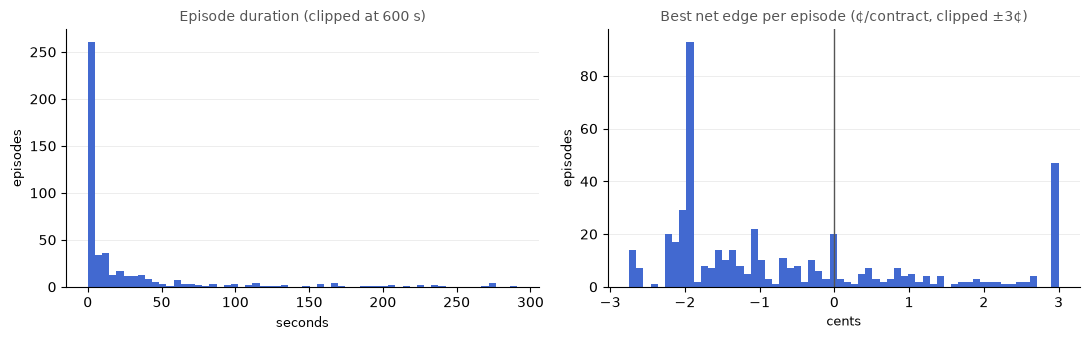

In [7]:
BLUE, INK, GRID = "#4269d0", "#555", "#e6e6e6"
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

ax = axes[0]
ax.hist(eps["duration_s"].clip(upper_bound=600), bins=60, color=BLUE)
ax.set_title("Episode duration (clipped at 600 s)", fontsize=10, color=INK)
ax.set_xlabel("seconds", fontsize=9)

ax = axes[1]
ax.hist((eps["max_net"] * 100).clip(-3, 3), bins=60, color=BLUE)
ax.axvline(0, color=INK, lw=1)
ax.set_title("Best net edge per episode (¢/contract, clipped ±3¢)", fontsize=10, color=INK)
ax.set_xlabel("cents", fontsize=9)

for ax in axes:
    ax.set_ylabel("episodes", fontsize=9)
    ax.grid(axis="y", color=GRID, lw=0.5)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

## Caveats

- The GAP_CUTOFF exclusion drops ~30% of matches (concentrated in spread/
  total line markets), holding roughly half the unfiltered top-of-book
  dollar total. Whether those are wrong matches or genuinely divergent
  contracts is unaudited; the cutoff itself is a judgment call on a smooth
  distribution.
- Top-of-book only; an edge on 3 contracts and on 300 look the same in the
  counts above (size shown only at the best tick).
- $ values assume every quoted fill completes. Live evidence from the
  poka-arb project (its `analysis/arbitrage/findings.md`): Polymarket's 1–3 s
  sports taker delay killed 10 of 11 hedge legs in its best-documented
  session, and each failed leg cost ~2.4¢ exit slippage — so quoted edge is
  an upper bound, not an expectation.
- One evening of data (~9 h, one slate of games); nothing here generalises yet.
- Durations are as-observed between book-change ticks; sub-tick dynamics and
  execution latency are ignored.
- Fee formulas assume both platforms' standard schedules; Kalshi notes some
  markets (elections, major sports events) carry different schedules.